<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
 MLR & Shadow Fading Analysis 
</p>

In [15]:
# Imports - core utils, data wrangling, ML, stats, and plotting

# Standard library
import os
import pickle
import re
import time
from math import sqrt

# Prevent BLAS oversubscription; we parallelize at sklearn/joblib level
os.environ["MKL_NUM_THREADS"]     = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"]     = "1"
os.environ["NUMEXPR_MAX_THREADS"] = "1"

# Data handling
import numpy as np
import pandas as pd
from IPython.display import display

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy.interpolate import interp1d
from scipy.stats import kstest, norm, t, skewnorm, cauchy

# Parallel
from joblib import Parallel, delayed

# Parallelism knob
N_JOBS = -1  # Use all available cores


#### Data paths, loading, and preparation

In [16]:
# Paths
TRAIN_CSV = "Data_Files/train.csv"
TEST_CSV  = "Data_Files/test.csv"
FOLDS_NPY = "Data_Files/train_folds.npy"
CV_SPLITS_NPZ = "Data_Files/train_time_series_cv_splits.npz"

# Load splits
df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)
fold_assignments = np.load(FOLDS_NPY)

cv_npz = np.load(CV_SPLITS_NPZ)
n_splits = int(cv_npz["n_splits"])
cv_splits = [
    (cv_npz[f"fold_{i}_train_idx"], cv_npz[f"fold_{i}_val_idx"])
    for i in range(n_splits)
]

# Feature/target setup
raw_feats = [
    "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature", "snr"
]
target_col = "PL"

required_cols = [target_col, "device_id", *raw_feats]

missing_train = [c for c in required_cols if c not in df_train.columns]
missing_test  = [c for c in required_cols if c not in df_test.columns]

if missing_train or missing_test:
    raise ValueError(
        f"Missing columns | train: {missing_train} | test: {missing_test}"
    )


def validate_cv_splits(cv_splits, fold_assignments, name="cv_splits"):
    fold_ids = sorted(np.unique(fold_assignments[fold_assignments >= 0]).astype(int).tolist())
    if len(cv_splits) != len(fold_ids):
        raise ValueError(f"{name} has {len(cv_splits)} splits but fold metadata has {len(fold_ids)} validation folds.")

    for fold_num, (tr_idx, val_idx) in enumerate(cv_splits):
        tr_idx = np.asarray(tr_idx, dtype=int)
        val_idx = np.asarray(val_idx, dtype=int)
        if tr_idx.size == 0 or val_idx.size == 0:
            raise ValueError(f"{name} fold {fold_num} has an empty train or validation index set.")
        if np.intersect1d(tr_idx, val_idx).size:
            raise ValueError(f"{name} fold {fold_num} has train/validation overlap.")
        if tr_idx.max() >= val_idx.min():
            raise ValueError(f"{name} fold {fold_num} trains on rows at or after its validation window.")

        expected_val_idx = np.flatnonzero(fold_assignments == fold_num)
        if not np.array_equal(val_idx, expected_val_idx):
            raise ValueError(f"{name} fold {fold_num} validation indices do not match train_folds.npy metadata.")


validate_cv_splits(cv_splits, fold_assignments)

# Train/test matrices
Xtr_raw = df_train[raw_feats].copy()
ytr_pl  = df_train[target_col].astype(float).values

Xte_raw = df_test[raw_feats].copy()
yte_pl  = df_test[target_col].astype(float).values


def slug(obj):
    """Filename-safe tag for model/config."""
    if isinstance(obj, dict) and obj:
        items = []
        for k in sorted(obj.keys()):
            v = obj[k]
            if isinstance(v, (float, np.floating)):
                v = float(v)
            items.append(f"{k}={v}")
        s = "__".join(items)
    else:
        s = str(obj) if obj not in (None, {}, []) else ""

    return re.sub(r"[^A-Za-z0-9._=-]+", "_", s).strip("_")


#### Physics-consistent linearization + helpers + model specs

In [17]:
# Linearize (Friis-adjusted): y_adj = PL - 20*log10(f)
d0 = 1.0
def z_of_d(d): 
    return 10.0*np.log10(np.clip(d.astype(float), 1e-6, None)/d0)
def f_term(f):
    return 20.0*np.log10(np.clip(f.astype(float), 1e-12, None))

# Adjusted targets
ftr_tr, ftr_te = f_term(Xtr_raw['frequency'].values), f_term(Xte_raw['frequency'].values)
ytr_adj, yte_adj = ytr_pl - ftr_tr, yte_pl - ftr_te

# Linear feature maps
cols = ['z_d','c_walls','w_walls','co2','humidity','pm25','pressure','temperature','snr']
Xtr_lin = pd.DataFrame({
    'z_d': z_of_d(Xtr_raw['distance'].values),
    'c_walls': Xtr_raw['c_walls'].values,
    'w_walls': Xtr_raw['w_walls'].values,
    'co2': Xtr_raw['co2'].values,
    'humidity': Xtr_raw['humidity'].values,
    'pm25': Xtr_raw['pm25'].values,
    'pressure': Xtr_raw['pressure'].values,
    'temperature': Xtr_raw['temperature'].values,
    'snr': Xtr_raw['snr'].values
}, columns=cols).values

Xte_lin = pd.DataFrame({
    'z_d': z_of_d(Xte_raw['distance'].values),
    'c_walls': Xte_raw['c_walls'].values,
    'w_walls': Xte_raw['w_walls'].values,
    'co2': Xte_raw['co2'].values,
    'humidity': Xte_raw['humidity'].values,
    'pm25': Xte_raw['pm25'].values,
    'pressure': Xte_raw['pressure'].values,
    'temperature': Xte_raw['temperature'].values,
    'snr': Xte_raw['snr'].values
}, columns=cols).values

# Param labels (for reporting)
param_names = [
    'PL(d0) [dB]', 'Path loss exponent (n)',
    'Brick Wall Loss (L_c) [dB]', 'Wood Wall Loss (L_w) [dB]',
    'CO2 coef. [dB/unit]', 'Humidity coef. [dB/%]',
    'PM2.5 coef. [dB/µg/m³]', 'Pressure coef. [dB/hPa]',
    'Temp. coef. [dB/°C]', 'SNR scaling (k_snr)'
]

# Helpers
def unscale_coefficients(pipeline):
    """Undo StandardScaler effect → coeffs in original units."""
    steps = pipeline.named_steps
    est = steps.get('ridge') or steps.get('lasso') or steps.get('elasticnet') or steps.get('linearregression')
    if 'standardscaler' not in steps:
        return float(est.intercept_), est.coef_.astype(float).copy()
    scaler = steps['standardscaler']
    beta_scaled = est.coef_.astype(float)
    mu, sig = scaler.mean_, scaler.scale_
    beta_orig = beta_scaled / sig
    intercept_orig = float(est.intercept_ - np.sum(beta_scaled * mu / sig))
    return intercept_orig, beta_orig

def fold_indices(folds, k):
    tr_idx, val_idx = cv_splits[k]
    expected_val_idx = np.flatnonzero(folds == k)
    if not np.array_equal(val_idx, expected_val_idx):
        raise ValueError(f"Fold {k}: validation indices do not match train_folds.npy metadata.")
    return tr_idx, val_idx

def rmse_r2_on_PL(y_true_pl, y_pred_adj, fterm):
    """Score in PL-domain (add back freq term)."""
    y_pred_pl = y_pred_adj + fterm
    rmse = sqrt(mean_squared_error(y_true_pl, y_pred_pl))
    r2   = r2_score(y_true_pl, y_pred_pl)
    return rmse, r2

# Model factories
def make_OLS(_): return make_pipeline(LinearRegression())
def make_Ridge(cfg): return make_pipeline(StandardScaler(), Ridge(alpha=cfg["alpha"], random_state=42))
def make_Lasso(cfg): return make_pipeline(StandardScaler(), Lasso(alpha=cfg["alpha"], max_iter=20000, random_state=42))
def make_ElasticNet(cfg): return make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=cfg["alpha"], l1_ratio=cfg["l1_ratio"], max_iter=20000, random_state=42)
)

# Grids
ridge_grid = [dict(alpha=a) for a in np.logspace(-4, 3, 15)]
lasso_grid = [dict(alpha=a) for a in np.logspace(-4, 1, 15)]
enet_grid  = [dict(alpha=a, l1_ratio=r) for a in np.logspace(-4, 1, 10) for r in (0.2, 0.5, 0.8)]

# Spec list
specs = [
    ("OLS",        make_OLS,        [dict()]),
    ("Ridge",      make_Ridge,      ridge_grid),
    ("Lasso",      make_Lasso,      lasso_grid),
    ("ElasticNet", make_ElasticNet, enet_grid),
]


#### Time-aware K-fold CV on the train split to pick the best config per MLR variant, then refit on full train subset

In [18]:
# K-fold CV over each MLR model
results = []
K = int(np.max(fold_assignments)) + 1

# Precompute indices once
folds = [fold_indices(fold_assignments, k) for k in range(K)]

print(f"Running CV for {len(specs)} MLR variants | K={len(folds)} folds | grid eval={'parallel' if (N_JOBS != 1) else 'sequential'}")

t0 = time.time()


def eval_cfg(factory, cfg, folds):
    tr_rmse_list, val_rmse_list, tr_r2_list, val_r2_list = [], [], [], []

    for tr_idx, val_idx in folds:
        X_tr, X_val = Xtr_lin[tr_idx], Xtr_lin[val_idx]
        y_tr, y_val = ytr_adj[tr_idx], ytr_adj[val_idx]
        ypl_tr, ypl_val = ytr_pl[tr_idx], ytr_pl[val_idx]
        f_tr, f_val = ftr_tr[tr_idx], ftr_tr[val_idx]

        pipe = factory(cfg)
        pipe.fit(X_tr, y_tr)

        y_tr_pred_adj = pipe.predict(X_tr)
        rmse_tr, r2_tr = rmse_r2_on_PL(ypl_tr, y_tr_pred_adj, f_tr)
        tr_rmse_list.append(rmse_tr)
        tr_r2_list.append(r2_tr)

        y_val_pred_adj = pipe.predict(X_val)
        rmse_val, r2_val = rmse_r2_on_PL(ypl_val, y_val_pred_adj, f_val)
        val_rmse_list.append(rmse_val)
        val_r2_list.append(r2_val)

    return {
        "cfg": cfg,
        "rmse_train_mean": float(np.mean(tr_rmse_list)),
        "rmse_train_sd":   float(np.std(tr_rmse_list)),
        "rmse_val_mean":   float(np.mean(val_rmse_list)),
        "rmse_val_sd":     float(np.std(val_rmse_list)),
        "r2_train_mean":   float(np.mean(tr_r2_list)),
        "r2_train_sd":     float(np.std(tr_r2_list)),
        "r2_val_mean":     float(np.mean(val_r2_list)),
        "r2_val_sd":       float(np.std(val_r2_list)),
    }


for name, factory, grid in specs:
    if len(grid) == 1:
        grid_results = [eval_cfg(factory, grid[0], folds)]
    else:
        grid_results = Parallel(n_jobs=N_JOBS, backend="threading", prefer="threads", verbose=0)(
            delayed(eval_cfg)(factory, cfg, folds) for cfg in grid
        )

    best_res = min(grid_results, key=lambda r: r["rmse_val_mean"])
    best_cfg = best_res["cfg"]
    best_cv = {k: v for k, v in best_res.items() if k != "cfg"}

    # Refit on all training data with best hyperparameters
    final_pipe = factory(best_cfg)
    final_pipe.fit(Xtr_lin, ytr_adj)

    # Test metrics in PL domain
    yte_pred_adj = final_pipe.predict(Xte_lin)
    test_rmse, test_r2 = rmse_r2_on_PL(yte_pl, yte_pred_adj, ftr_te)

    tag_cfg = slug(best_cfg)
    model_tag = f"MLR_{name}" if tag_cfg == "" else f"MLR_{name}__{tag_cfg}"

    # Coefficients back in original units
    intercept_orig, beta_orig = unscale_coefficients(final_pipe)
    coeffs = np.concatenate(([intercept_orig], beta_orig))
    coeffs_series = pd.Series(coeffs, index=param_names, name=name)

    results.append({
        "model":      name,
        "best_cfg":   best_cfg,
        "cv":         best_cv,
        "test":       {"rmse": float(test_rmse), "r2": float(test_r2)},
        "coeffs":     coeffs_series,
        "final_pipe": final_pipe,
        "model_tag":  model_tag,
    })

t1 = time.time()
print(f"\nDone processing in {(t1 - t0)/60:.2f} minutes.")


Running CV for 4 MLR variants | K=5 folds | grid eval=parallel

Done processing in 1.68 minutes.


#### MLR CV summary, CV-selected best model, saved TEST and OOF residuals


In [19]:
# Best MLR by mean CV validation RMSE
best_overall  = min(results, key=lambda r: r["cv"]["rmse_val_mean"])
best_name     = best_overall["model"]
best_cfg      = best_overall["best_cfg"]
best_long_tag = best_overall["model_tag"]


def mlr_short_tag(name: str) -> str:
    return f"MLR_{name}"


best_tag_short = mlr_short_tag(best_name)

# CV-only summary table on the training split
rows = []
for r in results:
    cfg = r.get("best_cfg", {}) if isinstance(r.get("best_cfg", {}), dict) else {"cfg": str(r.get("best_cfg"))}
    rows.append({
        "model":            mlr_short_tag(r["model"]),
        "is_best":          (r["model_tag"] == best_long_tag),
        "cv_rmse_val_mean": r["cv"]["rmse_val_mean"],
        "cv_rmse_val_sd":   r["cv"]["rmse_val_sd"],
        "cv_r2_val_mean":   r["cv"]["r2_val_mean"],
        "alpha":            cfg.get("alpha", np.nan),
        "l1_ratio":         cfg.get("l1_ratio", np.nan),
    })

mlr_cv_table = (pd.DataFrame(rows)
                .sort_values(["cv_rmse_val_mean", "cv_rmse_val_sd", "model"])
                .reset_index(drop=True))

display(mlr_cv_table)

# BEST residuals on TEST, using the final model already refit on full train
best_pipe = best_overall["final_pipe"]
yte_pred_adj = best_pipe.predict(Xte_lin)

PL_pred_test = yte_pred_adj + ftr_te
resid_test   = yte_pl - PL_pred_test

mlr_test_df = pd.DataFrame({
    "model":       "MLR_BEST",
    "split":       "test",
    "row_id":      np.arange(len(df_test), dtype=int),
    "time":        df_test.get("time", pd.Series(index=df_test.index, dtype=float)).values,
    "device_id":   df_test["device_id"].values,
    "distance":    df_test["distance"].values,
    "frequency":   df_test["frequency"].values,
    "c_walls":     df_test["c_walls"].values,
    "w_walls":     df_test["w_walls"].values,
    "co2":         df_test["co2"].values,
    "humidity":    df_test["humidity"].values,
    "pm25":        df_test["pm25"].values,
    "pressure":    df_test["pressure"].values,
    "temperature": df_test["temperature"].values,
    "snr":         df_test["snr"].values,
    "PL_true":     yte_pl,
    "PL_pred":     PL_pred_test,
    "resid_db":    resid_test,
})

os.makedirs("Residuals", exist_ok=True)

test_path = "Residuals/residuals_MLR_test.csv"
mlr_test_df.to_csv(test_path, index=False)
print(f"\n[TEST] Saved best MLR test residuals: {test_path}")

# OOF residuals for BEST on the train split
factory_for_best = next(f for (n, f, g) in specs if n == best_name)

y_pred_adj_oof = np.full(len(ytr_adj), np.nan, dtype=float)
for tr_idx, val_idx in folds:
    pipe = factory_for_best(best_cfg)
    pipe.fit(Xtr_lin[tr_idx], ytr_adj[tr_idx])
    y_pred_adj_oof[val_idx] = pipe.predict(Xtr_lin[val_idx])

mask = ~np.isnan(y_pred_adj_oof)

PL_pred_oof = y_pred_adj_oof[mask] + ftr_tr[mask]
resid_oof   = ytr_pl[mask] - PL_pred_oof

mlr_oof_df = pd.DataFrame({
    "model":       "MLR_BEST",
    "split":       "oof",
    "row_id":      np.arange(len(df_train), dtype=int)[mask],
    "fold":        fold_assignments.astype(int)[mask],
    "time":        df_train.get("time", pd.Series(index=df_train.index, dtype=float)).values[mask],
    "device_id":   df_train["device_id"].values[mask],
    "distance":    df_train["distance"].values[mask],
    "frequency":   df_train["frequency"].values[mask],
    "c_walls":     df_train["c_walls"].values[mask],
    "w_walls":     df_train["w_walls"].values[mask],
    "co2":         df_train["co2"].values[mask],
    "humidity":    df_train["humidity"].values[mask],
    "pm25":        df_train["pm25"].values[mask],
    "pressure":    df_train["pressure"].values[mask],
    "temperature": df_train["temperature"].values[mask],
    "snr":         df_train["snr"].values[mask],
    "PL_true":     ytr_pl[mask],
    "PL_pred":     PL_pred_oof,
    "resid_db":    resid_oof,
})

oof_path = "Residuals/residuals_MLR_oof.csv"
mlr_oof_df.to_csv(oof_path, index=False)
print(f"\n[OOF] Saved best MLR OOF residuals: {oof_path}")

# Save final BEST MLR model fitted on all training data
os.makedirs("Models", exist_ok=True)

best_model_path = "Models/mlr_final_model.pkl"

with open(best_model_path, "wb") as f:
    pickle.dump(best_pipe, f)

print(f"\nFinal BEST MLR model saved to {best_model_path}")
print(f"\nSelected model: {best_tag_short}")
print(f"\nBest config: {best_cfg}")


,model,is_best,cv_rmse_val_mean,cv_rmse_val_sd,cv_r2_val_mean,alpha,l1_ratio
0,MLR_ElasticNet,True,8.233291,0.557738,0.806084,0.059948,0.5
1,MLR_Ridge,False,8.240977,0.581891,0.805566,1000.000000,NaN
2,MLR_OLS,False,8.241577,0.582735,0.805532,NaN,NaN
3,MLR_Lasso,False,8.241578,0.582740,0.805532,0.000100,NaN



[TEST] Saved best MLR test residuals: Residuals/residuals_MLR_test.csv

[OOF] Saved best MLR OOF residuals: Residuals/residuals_MLR_oof.csv

Final BEST MLR model saved to Models/mlr_final_model.pkl

Selected model: MLR_ElasticNet

Best config: {'alpha': 0.05994842503189409, 'l1_ratio': 0.5}


#### Held-out test evaluation after CV selection


In [20]:
# Held-out test evaluation for all final fits, reported after CV selection
# The test split is not used for model selection.
test_rows = []
for res in results:
    te = res["test"]
    test_rows.append({
        "Model":    res["model"],
        "Selected": res["model"] == best_name,
        "Test RMSE": float(te["rmse"]),
        "Test R2":   float(te["r2"]),
    })

test_df = pd.DataFrame(test_rows)
display(test_df)


,Model,Selected,Test RMSE,Test R2
0,OLS,False,8.453447,0.798423
1,Ridge,False,8.454240,0.798385
2,Lasso,False,8.453403,0.798425
3,ElasticNet,True,8.484460,0.796941


#### Coefficient table (all models, final fits, original units)

In [21]:
# Collect coeffs side by side
coef_df = pd.concat([res['coeffs'] for res in results], axis=1)
coef_df.columns = [res['model'] for res in results]

print("\n Harmonized Coefficients (final all-train fits, original units) ")
display(coef_df)


 Harmonized Coefficients (final all-train fits, original units) 


,OLS,Ridge,Lasso,ElasticNet
PL(d0) [dB],2.305528,2.359624,2.298639,2.454082
Path loss exponent (n),3.866506,3.860131,3.866596,3.623919
Brick Wall Loss (L_c) [dB],6.830244,6.833462,6.829939,6.841285
Wood Wall Loss (L_w) [dB],1.977092,1.984641,1.976906,2.221589
CO2 coef. [dB/unit],-0.002355,-0.002361,-0.002354,-0.002453
Humidity coef. [dB/%],-0.091712,-0.091503,-0.091687,-0.074745
PM2.5 coef. [dB/µg/m³],-0.095295,-0.094584,-0.095261,-0.056054
Pressure coef. [dB/hPa],-0.008045,-0.008044,-0.008033,-0.004172
Temp. coef. [dB/°C],-0.141028,-0.141187,-0.140993,-0.137472
SNR scaling (k_snr),-2.034426,-2.033469,-2.034403,-1.980566


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
ANOVA and Shadow Fading Analysis

#### ANOVA reference model using the CV-consistent formulation


In [22]:
# ANOVA reference model using the same physics-consistent formulation as CV.
# Frequency is adjusted out of the target: y_adj = PL - 20log10(frequency).

df_anova = pd.DataFrame(Xtr_lin, columns=cols)
df_anova["PL_adj"] = ytr_adj

anova_formula = (
    "PL_adj ~ z_d + c_walls + w_walls + co2 + humidity + "
    "pm25 + pressure + temperature + snr"
)

anova_model = smf.ols(anova_formula, data=df_anova).fit()
anova_table = anova_lm(anova_model, typ=2)

display(anova_model.summary())
display(anova_table)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 PL_adj   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                 8.278e+05
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        15:41:05   Log-Likelihood:            -5.8281e+06
No. Observations:             1663627   AIC:                         1.166e+07
Df Residuals:                 1663617   BIC:                         1.166e+07
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.3055      0.254      9.078      0.000       1.808       2.803
z_d             3.8665      0.005    708.503      0.000       3.856       3.877
c_walls         6.8302      0.011    614.989      0.000       6.808       6.852
w_walls         1.9771      0.009    228.801      0.000       1.960       1.994
co2            -0.0024   5.39e-05    -43.682      0.000      -0.002      -0.002
humidity       -0.0917      0.001    -90.360      0.000      -0.094      -0.090
pm25           -0.0953      0.003    -31.960      0.000      -0.101      -0.089
pressure       -0.0080      0.001    -11.055      0.000      -0.009      -0.007
temperature    -0.1410      0.002    -81.221      0.000      -0.144      -0.138
snr            -2.0344      0.002  -1121.868      0.000      -2.038      -2.031
==============================================================================
Omnibus:                   374840.868   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1790778.664
Skew:                           1.020   Prob(JB):                         0.00
Kurtosis:                       7.655   Cond. No.                     2.54e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.54e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

,sum_sq,df,F,PR(>F)
z_d,3.243975e+07,1.0,5.019759e+05,0.000000e+00
c_walls,2.444156e+07,1.0,3.782110e+05,0.000000e+00
w_walls,3.383081e+06,1.0,5.235012e+04,0.000000e+00
co2,1.233094e+05,1.0,1.908102e+03,0.000000e+00
humidity,5.276524e+05,1.0,8.164945e+03,0.000000e+00
pm25,6.600891e+04,1.0,1.021428e+03,4.621196e-224
pressure,7.897391e+03,1.0,1.222050e+02,2.086524e-28
temperature,4.263145e+05,1.0,6.596833e+03,0.000000e+00
snr,8.133516e+07,1.0,1.258588e+06,0.000000e+00
Residual,1.075098e+08,1663617.0,NaN,NaN


#### Shadow-fading residual source


In [23]:
# Choose residual source for shadow-fading distribution analysis.
# Options:
#   "oof"  = out-of-fold train residuals from the CV-selected model
#   "test" = held-out test residuals from the final CV-selected model

RESIDUAL_SOURCE = "oof"  # change to "test" for held-out residuals

residual_sources = {
    "oof": {
        "values": resid_oof,
        "label": f"OOF residuals from {best_tag_short}",
    },
    "test": {
        "values": resid_test,
        "label": f"held-out test residuals from {best_tag_short}",
    },
}

if RESIDUAL_SOURCE not in residual_sources:
    raise ValueError(
        f"RESIDUAL_SOURCE must be one of {list(residual_sources)}; "
        f"got {RESIDUAL_SOURCE!r}"
    )

selected_residual_source = residual_sources[RESIDUAL_SOURCE]
residuals = pd.Series(
    selected_residual_source["values"],
    name=f"shadow_fading_resid_db_{RESIDUAL_SOURCE}",
).dropna().reset_index(drop=True)

n = len(residuals)
sorted_residuals = np.sort(residuals)
probabilities = (np.arange(1, n + 1) - 0.5) / n

print(f"Residual source: {selected_residual_source['label']}")
print(f"n = {n}")
print(f"Mean residual: {residuals.mean():.4f} dB")
print(f"Std residual:  {residuals.std(ddof=1):.4f} dB")


Residual source: OOF residuals from MLR_ElasticNet
n = 1663627
Mean residual: 0.0353 dB
Std residual:  8.1736 dB


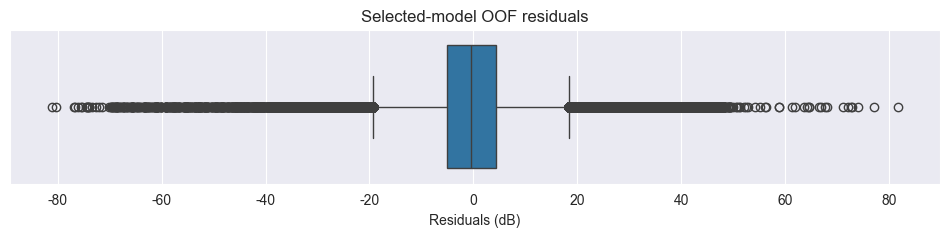

In [24]:
# Inspect selected-model residuals for outliers
plt.figure(figsize=(12, 2))
sns.boxplot(x=residuals)
plt.title("Selected-model OOF residuals")
plt.xlabel("Residuals (dB)")
plt.show()


#### Residual distribution fitting and diagnostics


In [28]:
# Fit candidate distributions to selected-model residuals

residuals_array = residuals.to_numpy().reshape(-1, 1)

# Normal
loc_norm, scale_norm = norm.fit(residuals)
normal_dist = norm(loc=loc_norm, scale=scale_norm)

# Skew-normal
shape_sn, loc_sn, scale_sn = skewnorm.fit(residuals)
skew_dist = skewnorm(shape_sn, loc=loc_sn, scale=scale_sn)

# Cauchy
cauchy_params = cauchy.fit(residuals)
cauchy_dist = cauchy(*cauchy_params)

# Student's t
df_t, loc_t, scale_t = t.fit(residuals)
t_dist = t(df=df_t, loc=loc_t, scale=scale_t)


def compute_aic_bic(log_likelihood, num_params, num_samples):
    aic = 2 * num_params - 2 * log_likelihood
    bic = num_params * np.log(num_samples) - 2 * log_likelihood
    return aic, bic


def gmm_cdf(x, gmm_model):
    cdf = np.zeros_like(x, dtype=float)
    for weight, mean, cov in zip(
        gmm_model.weights_,
        gmm_model.means_.flatten(),
        gmm_model.covariances_.flatten(),
    ):
        cdf += weight * norm.cdf(x, loc=mean, scale=np.sqrt(cov))
    return cdf


# GMM model selection: 1-4 components
gmm_models = []
gmm_diagnostics = []

for k in range(1, 5):
    gmm_k = GaussianMixture(n_components=k, random_state=42).fit(residuals_array)
    gmm_models.append(gmm_k)

    loglik_k = np.sum(gmm_k.score_samples(residuals_array))
    num_params = 3 * k - 1

    aic_k, bic_k = compute_aic_bic(loglik_k, num_params, n)
    ks_k = kstest(residuals, lambda x: gmm_cdf(x, gmm_k))

    gmm_diagnostics.append({
        "Distribution": f"GMM-{k}",
        "Components": k,
        "Log-Likelihood": loglik_k,
        "AIC": aic_k,
        "BIC": bic_k,
        "KS Statistic": ks_k.statistic,
        "KS p-value": ks_k.pvalue,
    })

gmm_diag_df = pd.DataFrame(gmm_diagnostics)
best_gmm_row = gmm_diag_df.loc[gmm_diag_df["BIC"].idxmin()]
best_gmm = gmm_models[int(best_gmm_row["Components"]) - 1]

# Non-GMM diagnostics
distribution_rows = []

for name, dist_obj, num_params in [
    ("Normal", normal_dist, 2),
    ("Skew-Normal", skew_dist, 3),
    ("Cauchy", cauchy_dist, 2),
    ("t-Distribution", t_dist, 3),
]:
    loglik = np.sum(np.log(dist_obj.pdf(residuals)))
    aic, bic = compute_aic_bic(loglik, num_params, n)
    ks = kstest(residuals, dist_obj.cdf)

    distribution_rows.append({
        "Distribution": name,
        "Components": np.nan,
        "Log-Likelihood": loglik,
        "AIC": aic,
        "BIC": bic,
        "KS Statistic": ks.statistic,
        "KS p-value": ks.pvalue,
    })

diagnostics = pd.concat(
    [pd.DataFrame(distribution_rows), gmm_diag_df],
    ignore_index=True,
)

diagnostics = diagnostics.round({
    "Log-Likelihood": 2,
    "AIC": 2,
    "BIC": 2,
    "KS Statistic": 4,
    "KS p-value": 4,
})

display(diagnostics)

best_fit = diagnostics.loc[diagnostics["BIC"].idxmin()]
print(f"\nBest fit by BIC: {best_fit['Distribution']}")
print(f"Best GMM components by BIC: {best_gmm.n_components}")


,Distribution,Components,Log-Likelihood,AIC,BIC,KS Statistic,KS p-value
0,Normal,NaN,-5855710.72,11711425.44,11711450.09,0.0516,0.0
1,Skew-Normal,NaN,-5798564.61,11597135.21,11597172.19,0.0389,0.0
2,Cauchy,NaN,-5971271.37,11942546.75,11942571.39,0.0796,0.0
3,t-Distribution,NaN,-5759964.42,11519934.84,11519971.82,0.0210,0.0
4,GMM-1,1.0,-5855710.72,11711425.44,11711450.09,0.0516,0.0
5,GMM-2,2.0,-5755979.91,11511969.83,11512031.45,0.0144,0.0
6,GMM-3,3.0,-5735218.98,11470453.97,11470552.56,0.0080,0.0
7,GMM-4,4.0,-5733740.02,11467502.05,11467637.62,0.0070,0.0



Best fit by BIC: GMM-4
Best GMM components by BIC: 4


In [29]:
# Print distribution parameters, including the BIC-selected GMM

def print_group(title, params):
    print(f"\033[1m{title}\033[0m")
    for name, val in params:
        print(f"{name}: {val:.4f}")
    print("-" * 50)


print_group("Normal Distribution", [("Mean", loc_norm), ("Std", scale_norm)])
print_group("Skew-Normal Distribution", [("Shape", shape_sn), ("Location", loc_sn), ("Scale", scale_sn)])

print(f"\033[1mGaussian Mixture Model ({best_gmm.n_components} components)\033[0m")
for i in range(best_gmm.n_components):
    cov = best_gmm.covariances_[i][0][0] if best_gmm.covariances_.ndim == 3 else best_gmm.covariances_[i]
    print(f"Component {i + 1}:")
    print(f"  Weight: {best_gmm.weights_[i]:.4f}")
    print(f"  Mean:   {best_gmm.means_[i][0]:.4f}")
    print(f"  Std:    {np.sqrt(cov):.4f}")
print("-" * 50)

print_group("Cauchy Distribution", [("Location", cauchy_params[0]), ("Scale", cauchy_params[1])])
print_group("t-Distribution", [("Degrees of Freedom", df_t), ("Location", loc_t), ("Scale", scale_t)])


Normal Distribution
Mean: 0.0353
Std: 8.1736
--------------------------------------------------
Skew-Normal Distribution
Shape: 1.9242
Location: -7.8939
Scale: 11.3877
--------------------------------------------------
Gaussian Mixture Model (4 components)
Component 1:
  Weight: 0.2487
  Mean:   6.5517
  Std:    4.3789
Component 2:
  Weight: 0.4163
  Mean:   -0.4774
  Std:    3.4520
Component 3:
  Weight: 0.0590
  Mean:   12.2981
  Std:    16.8354
Component 4:
  Weight: 0.2761
  Mean:   -7.6802
  Std:    3.9907
--------------------------------------------------
Cauchy Distribution
Location: -0.6229
Scale: 4.3268
--------------------------------------------------
t-Distribution
Degrees of Freedom: 5.0444
Location: -0.4605
Scale: 6.2757
--------------------------------------------------


#### Final residual diagnostic figure


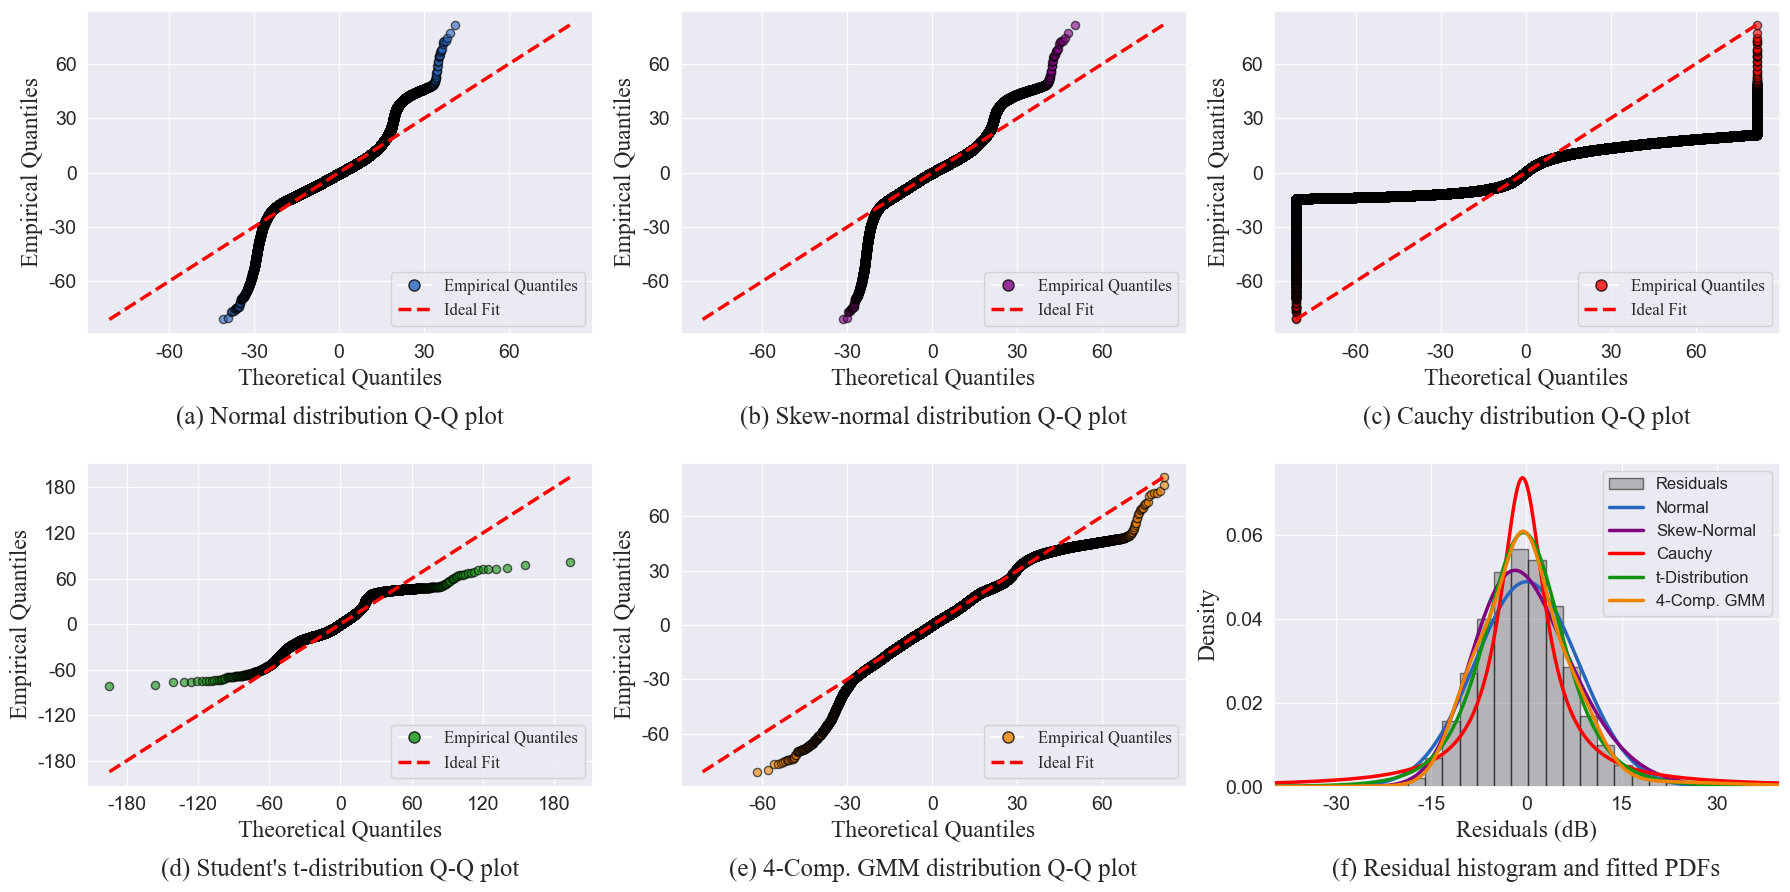

In [30]:
# Final residual diagnostic figure

tick_fontsize   = 14
axis_labelsize  = 17
legend_fontsize = 12
ab_fontsize     = 18
label_ypos      = -0.22

sns.set_style("darkgrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
qq_colors = {
    "normal": "#2766bd",
    "skew":   "purple",
    "cauchy": "red",
    "t":      "#119211",
    "gmm":    "#ef8301",
}


def add_qq(ax, theoretical, empirical, color, label, x_locator=30, y_locator=30):
    ax.scatter(theoretical, empirical, edgecolor="k", facecolor=color, alpha=0.6, s=35)

    min_val = min(theoretical.min(), empirical.min())
    max_val = max(theoretical.max(), empirical.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2.5)

    ax.set_xlabel("Theoretical Quantiles", fontsize=axis_labelsize, fontname="Times New Roman")
    ax.set_ylabel("Empirical Quantiles", fontsize=axis_labelsize, fontname="Times New Roman")
    ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
    ax.xaxis.set_major_locator(MultipleLocator(x_locator))
    ax.yaxis.set_major_locator(MultipleLocator(y_locator))
    ax.text(
        0.5, label_ypos, label,
        transform=ax.transAxes,
        fontsize=ab_fontsize,
        va="top",
        ha="center",
        fontname="Times New Roman",
    )

    legend_items = [
        Line2D([0], [0], marker="o", color="w", label="Empirical Quantiles",
               markerfacecolor=color, markeredgecolor="k", markersize=8, alpha=0.8),
        Line2D([0], [0], color="r", lw=2.5, linestyle="--", label="Ideal Fit"),
    ]

    leg = ax.legend(handles=legend_items, fontsize=legend_fontsize, loc="lower right", frameon=True)
    for text in leg.get_texts():
        text.set_fontname("Times New Roman")


# (a) Normal Q-Q
theoretical_norm = normal_dist.ppf(probabilities)
add_qq(
    axes[0, 0],
    theoretical_norm,
    sorted_residuals,
    qq_colors["normal"],
    "(a) Normal distribution Q-Q plot",
)

# (b) Skew-normal Q-Q
theoretical_skew = skew_dist.ppf(probabilities)
add_qq(
    axes[0, 1],
    theoretical_skew,
    sorted_residuals,
    qq_colors["skew"],
    "(b) Skew-normal distribution Q-Q plot",
)

# (c) Cauchy Q-Q
# Cauchy tails can dominate the axis; clipping is for visualization only.
theoretical_cauchy = cauchy_dist.ppf(probabilities)
theoretical_cauchy_plot = np.clip(theoretical_cauchy, residuals.min(), residuals.max())
add_qq(
    axes[0, 2],
    theoretical_cauchy_plot,
    sorted_residuals,
    qq_colors["cauchy"],
    "(c) Cauchy distribution Q-Q plot",
)

# (d) Student's t Q-Q
theoretical_t = t_dist.ppf(probabilities)
add_qq(
    axes[1, 0],
    theoretical_t,
    sorted_residuals,
    qq_colors["t"],
    "(d) Student's t-distribution Q-Q plot",
    x_locator=60,
    y_locator=60,
)

# (e) GMM Q-Q
x_grid = np.linspace(residuals.min(), residuals.max(), 200000)
cdf_grid = gmm_cdf(x_grid, best_gmm)
unique_cdf, unique_indices = np.unique(cdf_grid, return_index=True)
unique_x = x_grid[unique_indices]

ppf_func = interp1d(
    unique_cdf,
    unique_x,
    bounds_error=False,
    fill_value=(x_grid[0], x_grid[-1]),
)

theoretical_gmm = ppf_func(probabilities)

add_qq(
    axes[1, 1],
    theoretical_gmm,
    sorted_residuals,
    qq_colors["gmm"],
    f"(e) {best_gmm.n_components}-Comp. GMM distribution Q-Q plot",
)

# (f) Histogram + fitted PDFs
x_vals = np.linspace(residuals.min(), residuals.max(), 1000)

axes[1, 2].hist(
    residuals,
    bins=60,
    density=True,
    alpha=0.5,
    color="grey",
    edgecolor="black",
    label="Residuals",
)

axes[1, 2].plot(x_vals, normal_dist.pdf(x_vals), label="Normal", color=qq_colors["normal"], linewidth=2.5)
axes[1, 2].plot(x_vals, skew_dist.pdf(x_vals), label="Skew-Normal", color=qq_colors["skew"], linewidth=2.5)
axes[1, 2].plot(x_vals, cauchy_dist.pdf(x_vals), label="Cauchy", color=qq_colors["cauchy"], linewidth=2.5)
axes[1, 2].plot(x_vals, t_dist.pdf(x_vals), label="t-Distribution", color=qq_colors["t"], linewidth=2.5)

gmm_density = np.exp(best_gmm.score_samples(x_vals.reshape(-1, 1)))
axes[1, 2].plot(
    x_vals,
    gmm_density,
    label=f"{best_gmm.n_components}-Comp. GMM",
    color=qq_colors["gmm"],
    linewidth=2.5,
)

axes[1, 2].set_xlabel("Residuals (dB)", fontsize=axis_labelsize, fontname="Times New Roman")
axes[1, 2].set_ylabel("Density", fontsize=axis_labelsize, fontname="Times New Roman")
axes[1, 2].tick_params(axis="both", which="major", labelsize=tick_fontsize)
axes[1, 2].set_xlim(-40, 40)
axes[1, 2].xaxis.set_major_locator(MultipleLocator(15))
axes[1, 2].yaxis.set_major_locator(MultipleLocator(0.02))
axes[1, 2].legend(fontsize=legend_fontsize, loc="upper right")

axes[1, 2].text(
    0.5, label_ypos,
    "(f) Residual histogram and fitted PDFs",
    transform=axes[1, 2].transAxes,
    fontsize=ab_fontsize,
    va="top",
    ha="center",
    fontname="Times New Roman",
)

for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

plt.tight_layout(w_pad=0.8, h_pad=2.5)
plt.show()
